In [1]:
import glob
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import matplotlib
import ast
from matplotlib.lines import Line2D

from clonal_structure import *
from utils import *

## **Important!**

This notebook and the accompanying Python scripts are tailored to the data formats of this particular study only and are not intended as a general use tool. Function inputs require specific file naming to be tied to metadata. In principle, the method will work with any similar data, but changes to code to adapt to different metadata conventions will be needed.

## Data prep

In [2]:
# List of our study replicates for convenience.
replicates = ["PS_Bd_r01", "PS_Bd_r02", "PS_Bd_r03",
              "PS_Ct_r01", "PS_Ct_r02", "PS_Ct_r03",
              "PS_Pf_r01", "PS_Pf_r02", "PS_Pf_r03",
              "PS_Sc_r01", "PS_Sc_r02", "PS_Sc_r03",
              "PS_Sm_r01", "PS_Sm_r02", "PS_Sm_r03",
              "NP_Bd_r01", "NP_Bd_r02", "NP_Bd_r03",
              "NP_Ct_r01", "NP_Ct_r02", "NP_Ct_r03",
              "NP_Pf_r01", "NP_Pf_r02", "NP_Pf_r03",
              "NP_Sc_r01", "NP_Sc_r02", "NP_Sc_r03",
              "NP_Sm_r01", "NP_Sm_r02", "NP_Sm_r03"]

variant_data_dir = "/scratch/project_2000746/kiciadov/ngs/variants/mutect2/from_allas/snps_indels/"
pyclone_results_dir = "./pyclone_output/"
chosen_sample_df = pd.read_csv("chosen_sample_df.csv", index_col=0)
rep_time_df = pd.read_csv("rep_time.tsv", sep="\t", index_col=0)

## PyClone-VI Results

In [3]:
replicate = "PS_Bd_r01"
file = variant_data_dir + replicate + "_filtered_anno.vcf"
variant_df, _, _ = read_replicate_variant_data(replicate=replicate, 
                                               f=file, 
                                               sampling_data_file="Sampling_experiment_day_matches.txt")
chosen_samples = ast.literal_eval(chosen_sample_df.loc[replicate].values[0])
pyclone_results, pyclone_curves = process_pyclone_output(replicate, chosen_samples, pyclone_results_dir=pyclone_results_dir)

# We manually delete a few artefactual or very low frequency cohort curves.
if replicate == "PS_Pf_r01":
    pyclone_curves = np.delete(pyclone_curves, 5, 0)
    pyclone_results = pyclone_results[pyclone_results["cluster_id"] != 5]

if replicate == "PS_Pf_r02":
    pyclone_curves = np.delete(pyclone_curves, 2, 0) 
    pyclone_results = pyclone_results[pyclone_results["cluster_id"] != 2]
    dict_replace = {3: 2, 4: 3, 5: 4, 6: 5, 7: 6}
    pyclone_results = pyclone_results.replace({"cluster_id": dict_replace})

if replicate == "NP_Bd_r03":
    pyclone_curves = np.delete(pyclone_curves, 4, 0) 
    pyclone_results = pyclone_results[pyclone_results["cluster_id"] != 4]

if replicate == "NP_Pf_r03":
    pyclone_curves = np.delete(pyclone_curves, 2, 0) 
    pyclone_results = pyclone_results[pyclone_results["cluster_id"] != 2]
    dict_replace = {3: 2, 4: 3, 5: 4, 6: 5}
    pyclone_results = pyclone_results.replace({"cluster_id": dict_replace})



Computing the viable clonal structures (trees) requires manual input of cohort emergence order to resolve cases where more than one cohort emerges at the same time point. As a rule of thumb, cohorts that are not likely to be subclones of other cohorts are placed first. This could likely be automatized.

Below we read in a csv file of manually specified cohort emergence order (PyClone cohort number and time point index pair) for each of our study populations. Note that the order is specified after manually removing any artefactual cohorts.

In [4]:
clonal_order_df = pd.read_csv("clonal_order_df.csv", index_col=0)

In [5]:
order = np.array(ast.literal_eval(clonal_order_df.loc[replicate, "Order"]))
forest, tree_scores = compute_forest(pyclone_curves, order=order, emerging_cutoff=0.1, min_consistency_score=0.95, max_negative_difference=-0.01)

Begin compute trees...
Order: ['7' '6' '2' '1' '5' '4' '3']
Done.
5913 trees computed, scoring... 5040
Done.


Now we marginalize top 50 best scoring trees and select one with lowest marginalization cost.

In [6]:
# replicate, variant_df, results, curves, chosen_samples, rep_time_df, 
best_keys = list(tree_scores.sort_values("Total score").iloc[:50].index)
errors_df = pd.DataFrame(columns=["Error"])
for key in best_keys:
    _, error = compute_and_plot_clonal_structure(replicate=replicate,
                                                 tree=forest[key],
                                                 variant_df=variant_df,
                                                 pyclone_results=pyclone_results,
                                                 pyclone_curves=pyclone_curves,
                                                 chosen_samples=chosen_samples,
                                                 rep_time_df=rep_time_df,
                                                 show_plot=False, 
                                                 save_results=False)
    print(key, error)
    errors_df.loc[key] = error

print(errors_df[errors_df["Error"] == errors_df["Error"].min()])
top_scoring_key = errors_df[errors_df["Error"] == errors_df["Error"].min()].index[0]

4603 0.45532114069865404
4602 0.45432214069865445
4596 0.6446619946102269
4595 0.6436629946102278
4601 0.8497698194745459
4636 0.7076905010659938
4638 0.7076905010659932
4643 0.7076905010659933
4645 0.7086895010659935
4609 0.7545014592862103
4610 0.7535024592862088
4594 1.0699313535912864
2083 0.5111054818727679
2082 0.5111054818727686
4637 0.9664328968385226
4644 0.9741236432784398
2076 0.6992030329532752
2075 0.6992030329532761
4599 1.3628846400133416
4608 1.1489501380621006
4650 1.0078698196535463
4652 1.0078698196535467
4582 1.5370145016587062
4581 1.5370145016587058
2081 0.9069609049300412
4592 1.5522254939249178
2116 0.7633469173293682
2118 0.7633469173293674
2125 0.7643459173293674
2123 0.7643459173293673
2089 0.8084970547377719
2090 0.8084970547377706
4651 1.2656132154260737
2074 1.1258159192203454
4634 1.6162530003806825
4641 1.6162530003806863
2117 1.0207664352500687
2124 1.0304397557431288
4580 1.931890994881119
4606 1.6620649586008973
4622 1.78938386202605
4624 1.7893838620

,Error
4602,0.454322


In [16]:
!mkdir -p ./inference_results

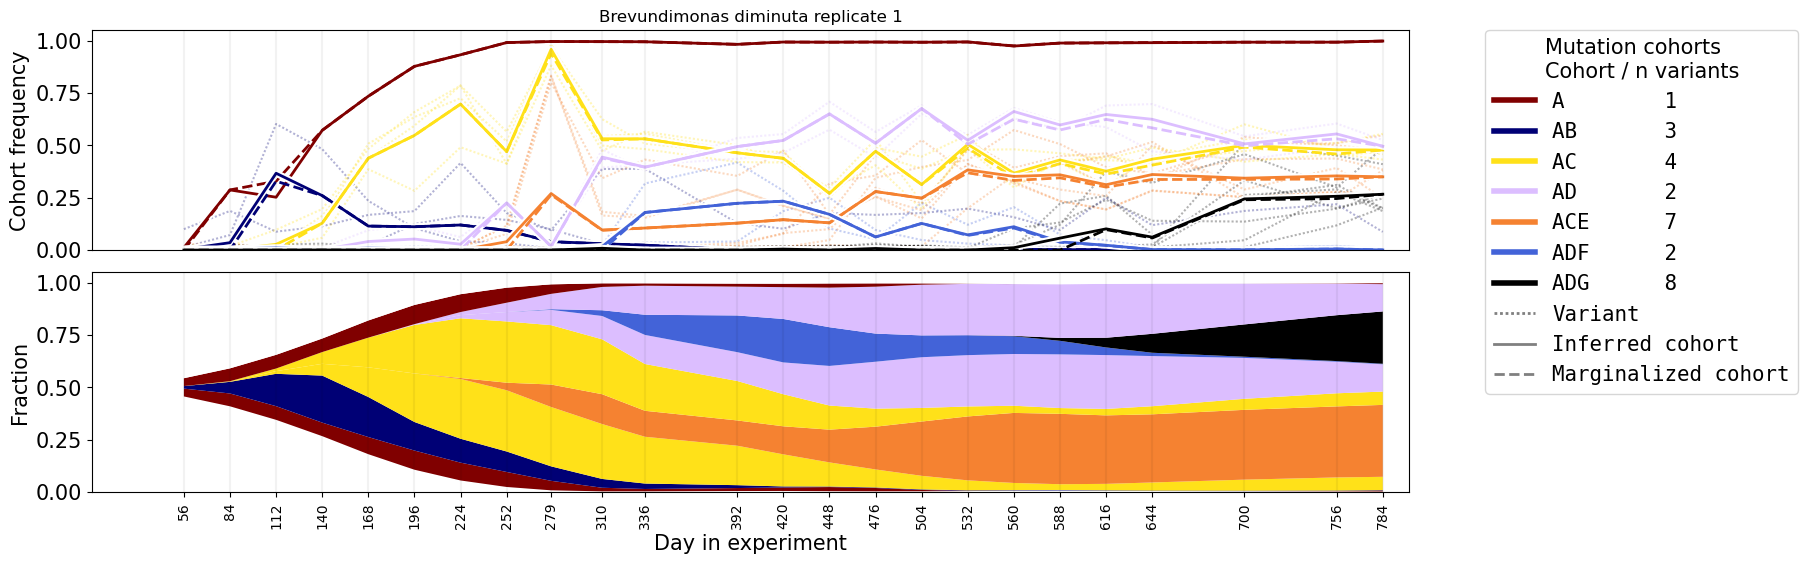

Marginalization cost:  0.45432214069865445


In [17]:
clone_fractions_df, error = compute_and_plot_clonal_structure(replicate=replicate,
                                                              tree=forest[top_scoring_key],
                                                              variant_df=variant_df,
                                                              pyclone_results=pyclone_results,
                                                              pyclone_curves=pyclone_curves,
                                                              chosen_samples=chosen_samples,
                                                              rep_time_df=rep_time_df,
                                                              save_prefix="./inference_results/" + replicate,
                                                              show_plot=True, 
                                                              save_results=True, 
                                                              plot_pop_sizes=False)
print("Marginalization cost: ", error)

The resulting clonal hierarchy can now be represented as a tree (Newick format) and analyzed further. Structure to Newick tree format conversion is manual.

In this example, Newick tree for population "PS_Bd_r01", complete with manually computed clade survival times, is "((((A:27,(ADF:252,(ADG:168,AD:168):280):84):112,(ACE:505,AC:505):139):28,AB:140):28,0:140):84;"